In [39]:
from google import genai
from google.genai import types
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import math

### Setting up Gemini API Key

In [8]:
# Load environment variables from .env
load_dotenv()

# The client gets the API key from the environment variable `GEMINI_API_KEY`.
client = genai.Client()

## Functions to prompt Gemini VLM through API

In [35]:
def load_asset_images(asset_ID, attribute_data, inline_threshold_mb=2):
    """
    For a given asset_ID, find all associated image paths in attribute_data,
    then load them as:
      - Uploaded files (if > inline_threshold_mb)
      - Inline bytes (if ≤ inline_threshold_mb)
    
    Returns a list of file parts suitable for model.generate_content().
    """
    
    image_paths = (
        attribute_data.loc[attribute_data["asset_id"] == asset_ID, "image_path"]
        .dropna()
        .tolist()
    )

    parts = []

    for path in image_paths:
        fixed_path = path.replace("data/", "../data/raw/", 1)
        if not os.path.exists(fixed_path):
            print(f"⚠️ Warning: Image not found: {fixed_path}")
            continue

        size_mb = os.path.getsize(fixed_path) / (1024 * 1024)

        if size_mb > inline_threshold_mb:
            # Upload large image
            uploaded = client.files.upload(file=fixed_path)
            parts.append(uploaded)

        else:
            # Inline small image
            with open(fixed_path, "rb") as f:
                img_bytes = f.read()

            mime = "image/png" if fixed_path.lower().endswith("png") else "image/jpeg"

            parts.append(
                types.Part.from_bytes(
                    data=img_bytes,
                    mime_type=mime
                )
            )

    return parts

In [77]:
def predict_stairs_attributes(image_parts, model_name):
    """
    Given several images of one stair asset, predict its attributes.
    """

    prompt = """
    You are an expert in park infrastructure analysis.
    
    Using ALL provided images of this single stair asset, identify the most likely 
    attribute values. For each of the following attributes, the possible
    values are given. Predict only ONE value out of the given options for each 
    attribute, and provide a confidence score for each attribute prediction.
    
    Attributes to predict:
    - Fall Height (low (<0.5m) / medium (0.5m-1.2m) / high (>1.2m))
    - Has Pedestrian Railing (2 railings / 1 railing / no railings)
    - Material (PVC / Gravel / Natural Surface / Earth-filled / Aluminum / Metal / Steel / Rock/Stone / Concrete / Box Step / Timber/Wood)
    - Number of Steps
    - Structure Position (Elevated / At-Grade / Other)
    
    Return the result with attribute:value pairs and associated confidence scores.
    
    If you are not confident about an answer, say "Unable to Determine".
    """

    response = client.models.generate_content(
        model=model_name,
        contents=[prompt] + image_parts
    )
    
    print(response.text)

    return response.text

In [44]:
def show_asset_images(df, asset_id, max_cols=4, figsize=(6, 6)):
    """
    Display all images for a given asset_id in a tiled grid.
    """

    # Get paths
    paths = (
        df.loc[df['asset_id'] == asset_id, "image_path"]
        .dropna()
        .tolist()
    )

    if len(paths) == 0:
        print("No images found for this asset.")
        return

    # Fix paths if necessary
    # (Modify this if your image directory differs)
    fixed_paths = [p.replace("data/", "../data/raw/", 1) for p in paths]

    # Grid layout
    n = len(fixed_paths)
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

    # Flatten axes for easier indexing
    axes = axes.flatten() if n > 1 else [axes]

    for ax, img_path in zip(axes, fixed_paths):
        if not os.path.exists(img_path):
            ax.set_title("Missing")
            ax.axis("off")
            continue

        img = Image.open(img_path)
        img = ImageOps.exif_transpose(img)  # correct orientation

        ax.imshow(img)
        ax.axis("off")

    # Turn off any extra axes
    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Loading training dataset

In [31]:
train_df = pd.read_csv("../data/processed/train.csv")
train_df.head()

,image_path,file_exists,asset_id,profile_id,profile_name,description,file_id,filename,attr_abutment_material,attr_bridge_type,...,"attr_material_frame,_tank,_body",attr_number_of_steps,attr_structure_material,attr_structure_position,attr_width,Length measured by staff,length_bin,width_bin,fall_height_bin,steps_bin
0,data/citywide/images/337/48117/86997__AST_EX_2...,True,48117,337,Boardwalk < 1.2m High,Item description: PRESSURE TREATED WOOD UNIT; ...,86997,AST_EX_20250818_114301.jpeg,NaN,NaN,...,Timber/Wood,NaN,Timber,NaN,1.0,True,long (>100m),standard (0.9-1.5m),NaN,NaN
1,data/citywide/images/337/46933/59582__IMG_2182...,True,46933,337,Boardwalk < 1.2m High,"2""x8""x8' decking on 6""x6"" sills, # sills & # s...",59582,IMG_2182.JPG,NaN,NaN,...,Timber/Wood,NaN,Timber,NaN,0.5,True,long (>100m),narrow (<0.9m),NaN,NaN
2,data/citywide/images/337/47664/86079__AST_EX_2...,True,47664,337,Boardwalk < 1.2m High,Bishop Bay Hs Backcountry; Boardwalk at Bishop...,86079,AST_EX_20250803_081025.jpeg,NaN,NaN,...,Timber/Wood,NaN,Timber,NaN,NaN,True,long (>100m),NaN,NaN,NaN
3,data/citywide/images/337/46615/7974__AST_EX_20...,True,46615,337,Boardwalk < 1.2m High,Ancient Forest Day Use; Specifications: Cedar/...,7974,AST_EX_20210725_102426.jpeg,NaN,NaN,...,Timber/Wood,NaN,Timber,NaN,NaN,True,long (>100m),NaN,NaN,NaN
4,data/citywide/images/337/46615/7975__AST_EX_20...,True,46615,337,Boardwalk < 1.2m High,Ancient Forest Day Use; Specifications: Cedar/...,7975,AST_EX_20210725_102345.jpeg,NaN,NaN,...,Timber/Wood,NaN,Timber,NaN,NaN,True,long (>100m),NaN,NaN,NaN


# Model #1: Gemini 3 Flash

## Test #1: Stair Asset 53688

In [80]:
asset_id = 53688
stair = train_df[train_df['asset_id'] == asset_id]
stair[["asset_id", "description", "attr_fall_height", "attr_has_pedestrian_railing", "attr_material_frame,_tank,_body", "attr_number_of_steps", "attr_structure_position"]]

,asset_id,description,attr_fall_height,attr_has_pedestrian_railing,"attr_material_frame,_tank,_body",attr_number_of_steps,attr_structure_position
1726,53688,Hemer Type I Trails; Concrete steps ( four ste...,NaN,NaN,Concrete,NaN,At-Grade
1727,53688,Hemer Type I Trails; Concrete steps ( four ste...,NaN,NaN,Concrete,NaN,At-Grade
1728,53688,Hemer Type I Trails; Concrete steps ( four ste...,NaN,NaN,Concrete,NaN,At-Grade


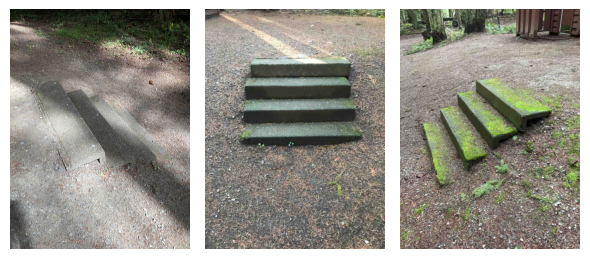

In [81]:
show_asset_images(train_df, asset_id)

In [82]:
parts = load_asset_images(asset_id, train_df)
prediction = predict_stairs_attributes(image_parts=parts, model_name="gemini-3-flash-preview")

Based on the provided images of the stair asset, here is the analysis of its attributes:

*   **Fall Height:** medium (0.5m-1.2m)
    *   **Confidence:** 0.80 (With 4 steps, each typically having a riser of about 15cm, the total height is approximately 0.6m, which falls into the medium range.)
*   **Has Pedestrian Railing:** no railings
    *   **Confidence:** 1.00 (No railings are visible from any angle in the three images.)
*   **Material:** Concrete
    *   **Confidence:** 0.95 (The steps appear to be made of uniform, precast concrete segments.)
*   **Number of Steps:** 4
    *   **Confidence:** 1.00 (Four distinct steps are clearly visible in all images.)
*   **Structure Position:** At-Grade
    *   **Confidence:** 0.95 (The steps are set directly into the natural slope of the trail surface.)


## Test #2: Stair Asset

In [83]:
asset_id = 55654
stair = train_df[train_df['asset_id'] == asset_id]
stair[["asset_id", "description", "attr_fall_height", "attr_has_pedestrian_railing", "attr_material_frame,_tank,_body", "attr_number_of_steps", "attr_structure_position"]]

,asset_id,description,attr_fall_height,attr_has_pedestrian_railing,"attr_material_frame,_tank,_body",attr_number_of_steps,attr_structure_position
1745,55654,Silver Spray; OUTHOUSE STAIRS; ladder,NaN,1 railing,NaN,NaN,Other


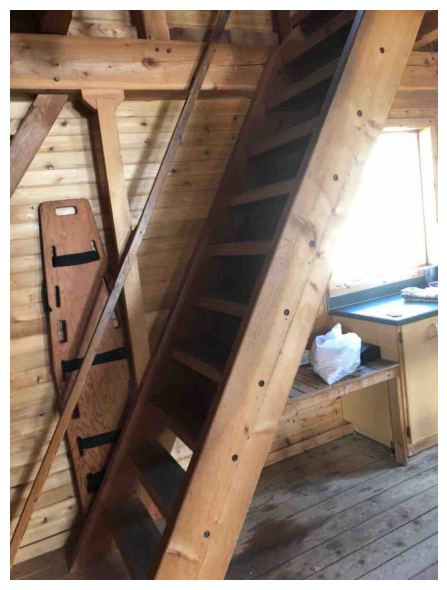

In [84]:
show_asset_images(train_df, asset_id)

In [85]:
parts = load_asset_images(asset_id, train_df)
prediction = predict_stairs_attributes(image_parts=parts,  model_name="gemini-3-flash-preview")

- **Fall Height:** high (>1.2m) | Confidence: 0.95
- **Has Pedestrian Railing:** 1 railing | Confidence: 0.9
- **Material:** Timber/Wood | Confidence: 0.99
- **Number of Steps:** 10 | Confidence: 0.8
- **Structure Position:** Elevated | Confidence: 0.9


### Test #3: Stair Asset 57613

In [87]:
asset_id = 57613
stair = train_df[train_df['asset_id'] == asset_id]
stair[["asset_id", "description", "attr_fall_height", "attr_has_pedestrian_railing", "attr_material_frame,_tank,_body", "attr_number_of_steps", "attr_structure_position"]]

,asset_id,description,attr_fall_height,attr_has_pedestrian_railing,"attr_material_frame,_tank,_body",attr_number_of_steps,attr_structure_position
1765,57613,Montague Harbour Group Site; concrete,NaN,2 railings,Concrete,NaN,At-Grade
1766,57613,Montague Harbour Group Site; concrete,NaN,2 railings,Concrete,NaN,At-Grade


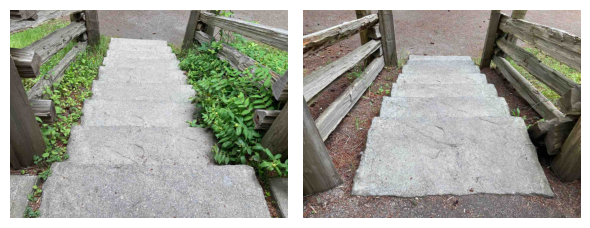

In [88]:
show_asset_images(train_df, asset_id)

In [89]:
parts = load_asset_images(asset_id, train_df)
prediction = predict_stairs_attributes(image_parts=parts, model_name="gemini-3-flash-preview")

- **Fall Height**: high (>1.2m) (Confidence: 0.85)
- **Has Pedestrian Railing**: 2 railings (Confidence: 0.95)
- **Material**: Concrete (Confidence: 0.9)
- **Number of Steps**: 8 (Confidence: 0.9)
- **Structure Position**: At-Grade (Confidence: 1.0)


## Test #4: Stair Asset 80452

In [91]:
asset_id = 80452
stair = train_df[train_df['asset_id'] == asset_id]
stair[["asset_id", "description", "attr_fall_height", "attr_has_pedestrian_railing", "attr_material_frame,_tank,_body", "attr_number_of_steps", "attr_structure_position"]]

,asset_id,description,attr_fall_height,attr_has_pedestrian_railing,"attr_material_frame,_tank,_body",attr_number_of_steps,attr_structure_position
1840,80452,Stone steps by gazebo sign and lily pond; stone,NaN,No railings,Rock/Stone,NaN,At-Grade


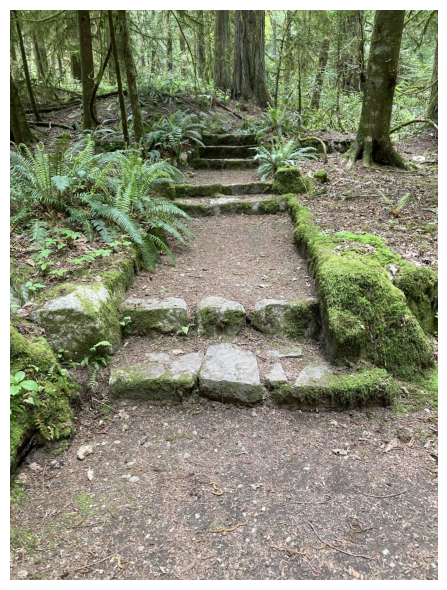

In [92]:
show_asset_images(train_df, asset_id)

In [93]:
parts = load_asset_images(asset_id, train_df)
prediction = predict_stairs_attributes(image_parts=parts, model_name="gemini-3-flash-preview")

Based on the image provided, here is the analysis of the stair asset:

*   **Fall Height:** low (<0.5m)
    *   **Confidence Score:** 95%
    *   *Reasoning:* The steps are built into a gentle natural slope, and there are no significant vertical drop-offs adjacent to the path that exceed 0.5 meters.
*   **Has Pedestrian Railing:** no railings
    *   **Confidence Score:** 100%
    *   *Reasoning:* There are no railings visible on either side of the stairway.
*   **Material:** Rock/Stone
    *   **Confidence Score:** 98%
    *   *Reasoning:* The risers and edges of the steps are constructed from large, natural stones/rocks.
*   **Number of Steps:** 6
    *   **Confidence Score:** 90%
    *   *Reasoning:* There are three distinct tiers, each appearing to have two stone-faced risers, totaling 6 steps.
*   **Structure Position:** At-Grade
    *   **Confidence Score:** 95%
    *   *Reasoning:* The stairway is built directly into the existing ground and follows the natural topography.


## Test #5: Stair Asset

In [94]:
asset_id = 108027
stair = train_df[train_df['asset_id'] == asset_id]
stair[["asset_id", "description", "attr_fall_height", "attr_has_pedestrian_railing", "attr_material_frame,_tank,_body", "attr_number_of_steps", "attr_structure_position"]]

,asset_id,description,attr_fall_height,attr_has_pedestrian_railing,"attr_material_frame,_tank,_body",attr_number_of_steps,attr_structure_position
2290,108027,7 Log style steps. Pretty rotten but sturdy. 15%,NaN,NaN,NaN,NaN,NaN
2291,108027,7 Log style steps. Pretty rotten but sturdy. 15%,NaN,NaN,NaN,NaN,NaN


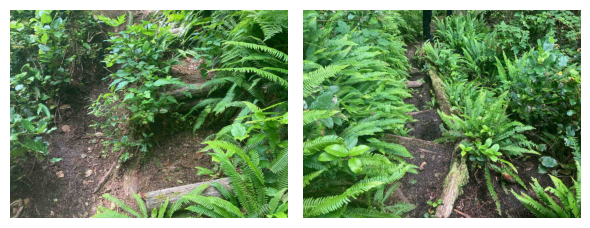

In [95]:
show_asset_images(train_df, asset_id)

In [96]:
parts = load_asset_images(asset_id, train_df)
prediction = predict_stairs_attributes(image_parts=parts, model_name="gemini-3-flash-preview")

Based on the visual analysis of the provided images, here are the predicted attribute values for the stair asset:

*   **Fall Height:** medium (0.5m-1.2m)
    *   **Confidence Score:** 80% (The total rise of the 7 steps appears to be within this range, roughly around 1 meter).
*   **Has Pedestrian Railing:** no railings
    *   **Confidence Score:** 99% (There is no railing infrastructure present on either side of the trail).
*   **Material:** Timber/Wood
    *   **Confidence Score:** 90% (The risers are clearly made from natural wood logs, which is the primary structural component).
*   **Number of Steps:** 7
    *   **Confidence Score:** 85% (Counting from the bottom to where the person is standing at the top level reveals approximately 7 distinct log risers).
*   **Structure Position:** At-Grade
    *   **Confidence Score:** 95% (The steps are built directly into the existing earthen slope of the trail).
